# Customer Segmentation & Retention Priority Analysis
### RFM Analysis (Online Retail II Dataset)

**Business question:** Which customer segments are most valuable, and which are at risk of churning and how should retention budget be allocated across them?

**Approach:** Recency, Frequency, Monetary (RFM) analysis on transaction-level data, scored and grouped into actionable segments.

## 1. Load & Clean Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/online_retail_II.csv', encoding='latin1')
print("Raw shape:", df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


Raw shape: (541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


**Cleaning steps:**
- Drop rows with missing `Customer ID` since these transactions can't be tied to a customer and can't be segmented
- Drop cancelled orders (Invoice numbers starting with 'C')
- Drop rows with non-positive Quantity or Price (these are returns, adjustments, or data errors, not real purchases)

In [3]:
df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')
df['TotalPrice'] = df['Quantity'] * df['Price']

print("Cleaned shape:", df.shape)
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print("Unique customers:", df['Customer ID'].nunique())

Cleaned shape: (397885, 9)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4338


## 2. Exploratory Data Analysis

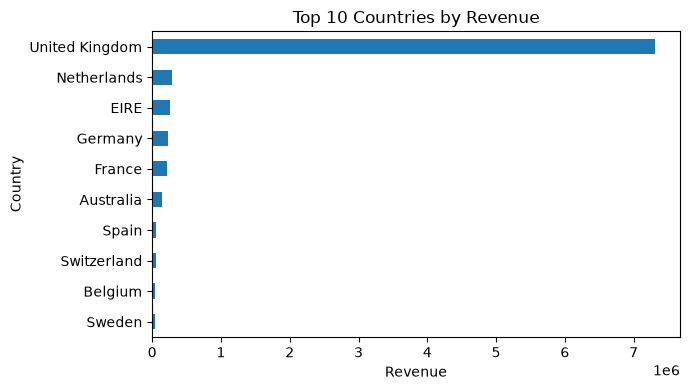

In [4]:
# Revenue by country (sanity check on data composition)
country_rev = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
country_rev.plot(kind='barh', figsize=(7,4))
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

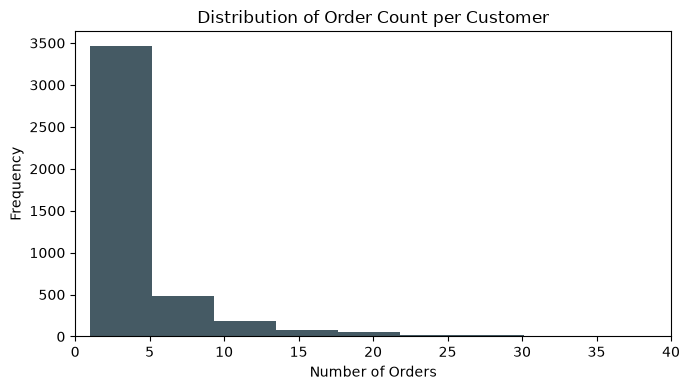

In [5]:
# Purchases per customer (right-skewed distribution)
purchase_counts = df.groupby('Customer ID')['Invoice'].nunique()
purchase_counts.plot(kind='hist', bins=50, figsize=(7,4), color='#455A64')
plt.title('Distribution of Order Count per Customer')
plt.xlabel('Number of Orders')
plt.xlim(0, 40)
plt.tight_layout()
plt.show()

The distribution above is heavily right-skewed. Most customers order only once or twice, while a small group orders repeatedly

## 3. Build RFM Table

For each customer, compute:
- **Recency** = days since their most recent purchase (as of one day after the last date in the dataset)
- **Frequency** = number of distinct orders placed
- **Monetary** = total amount spent

In [6]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.270609
std,1721.808492,100.014169,7.697998,8989.229895
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


## 4. Score & Segment Customers

Each of R, F, and M is split into quintiles (1-5). For Recency, a **lower** number of days is better, so the scoring is reversed (5 = most recent).

Customers are then mapped into named segments based on their combined scores. This uses standard, widely-used RFM segment definitions rather than an arbitrary cutoff, so the thresholds are defensible.

In [8]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm['Segment'].value_counts()

Segment
Needs Attention    1021
Champions           962
Hibernating         824
Loyal Customers     758
At Risk             454
New Customers       319
Name: count, dtype: int64

**Segment definitions:**
- **Champions** = bought recently, buy often, spend the most
- **Loyal Customers** = solid, consistent buyers, though not always the most recent
- **At Risk** = used to buy frequently and spend well, but haven't purchased in a while
- **Needs Attention** = mixed signals, average across the board
- **Hibernating** = low recency, frequency, and spend (largely disengaged)
- **New Customers** = recent first-time buyers, not enough history to classify further

## 5. Segment Profiles

In [9]:
summary = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(1)

summary['Pct_Customers'] = (summary['Customers'] / summary['Customers'].sum() * 100).round(1)
summary['Pct_Revenue'] = (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(1)
summary = summary.sort_values('Total_Revenue', ascending=False)
summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_Customers,Pct_Revenue
Segment,,,,,,,
Champions,962,12.9,11.1,6038.8,5809341.1,22.2,65.2
Loyal Customers,758,35.7,4.1,1842.6,1396709.4,17.5,15.7
At Risk,454,141.6,3.8,1634.7,742150.0,10.5,8.3
Needs Attention,1021,101.4,1.7,614.4,627288.0,23.5,7.0
Hibernating,824,228.5,1.0,230.3,189770.9,19.0,2.1
New Customers,319,18.5,1.2,458.2,146166.6,7.4,1.6


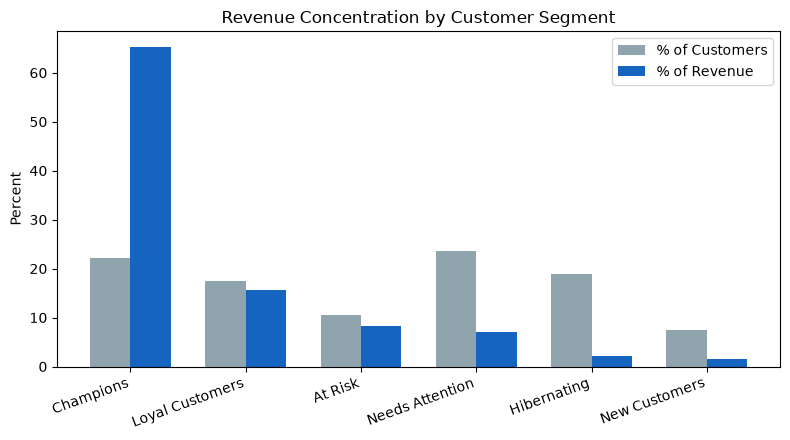

In [10]:
order = ['Champions', 'Loyal Customers', 'At Risk', 'Needs Attention', 'Hibernating', 'New Customers']
plot_df = summary.loc[order]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(order))
width = 0.35
ax.bar([i - width/2 for i in x], plot_df['Pct_Customers'], width, label='% of Customers', color='#90A4AE')
ax.bar([i + width/2 for i in x], plot_df['Pct_Revenue'], width, label='% of Revenue', color='#1565C0')
ax.set_xticks(list(x))
ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_ylabel('Percent')
ax.set_title('Revenue Concentration by Customer Segment')
ax.legend()
plt.tight_layout()
plt.show()

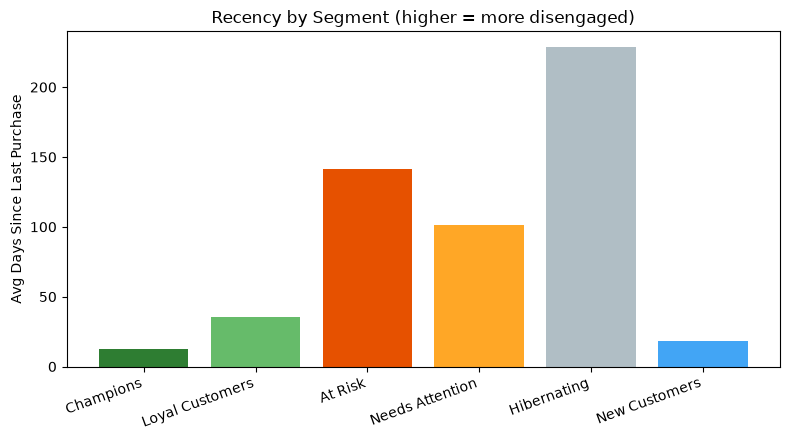

In [11]:
colors = ['#2E7D32', '#66BB6A', '#E65100', '#FFA726', '#B0BEC5', '#42A5F5']
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(order, plot_df['Avg_Recency'], color=colors)
ax.set_ylabel('Avg Days Since Last Purchase')
ax.set_title('Recency by Segment (higher = more disengaged)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()